# 14. Monitoring and Drift Demo

The API can be technically healthy while the model becomes less useful in practice. A `/health` endpoint only tells us that the service is running. It does not tell us whether incoming customers still look like the training data.

In this notebook, we use a small local monitoring setup:

- the FastAPI service logs incoming requests and predictions to SQLite;
- the database is stored in `monitoring/predictions.db`;
- Docker Compose mounts `monitoring/` as a writable volume;
- this notebook compares logged requests with reference training data.

The structure follows common patterns from model monitoring tools such as Evidently, NannyML, Azure ML Model Monitoring, AWS SageMaker Model Monitor, and Vertex AI Model Monitoring: reference data versus current data, data quality checks, data drift checks, prediction monitoring, and alert-style summaries.

## 1. Why Monitoring Matters

Machine learning systems can fail silently. The API may still return status code `200`, but the world around the model may have changed.

Examples:

- new customers have much shorter tenure than the training population;
- more customers use month-to-month contracts;
- a pricing campaign changes `MonthlyCharges`;
- a new sales channel brings in customers with different service bundles.

These changes do not necessarily crash the pipeline, but they can make model predictions less reliable.

In [23]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, ks_2samp


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root. Please run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import clean_telco_data, load_raw_data
from src.serving.monitoring import get_monitoring_db_path, load_prediction_logs

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

plt.style.use("default")


## 2. Reference Data

The reference distribution usually comes from the training data. In a production setup, teams often define a specific reference window, for example the training snapshot or the last stable production month.

Here, we use the cleaned Telco training dataset as reference.

In [24]:
reference_df = clean_telco_data(load_raw_data(RAW_DATA_PATH))
reference_df[["tenure", "MonthlyCharges", "TotalCharges", "Contract", "InternetService", "PaymentMethod"]].head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
0,1,29.85,29.85,Month-to-month,DSL,Electronic check
1,34,56.95,1889.50,One year,DSL,Mailed check
2,2,53.85,108.15,Month-to-month,DSL,Mailed check
3,45,42.30,1840.75,One year,DSL,Bank transfer (automatic)
4,2,70.70,151.65,Month-to-month,Fiber optic,Electronic check


## 3. Prediction Logs

The API writes one row per successful prediction. Each row contains:

- timestamp;
- selected input features;
- the full original request as JSON;
- prediction probability and class;
- model name and model version.

If no API calls have been logged yet, this notebook creates a synthetic current sample for demonstration. That sample is not written to the database.

In [25]:
monitoring_db_path = get_monitoring_db_path()
logged_predictions = load_prediction_logs(monitoring_db_path)

if logged_predictions.empty:
    rng = np.random.default_rng(42)
    current_df = reference_df.sample(n=400, random_state=42).copy()

    # Demonstration drift: more short-tenure, month-to-month, fiber customers.
    current_df["tenure"] = np.maximum(0, (current_df["tenure"] * rng.uniform(0.15, 0.65, len(current_df))).round())
    current_df.loc[current_df.sample(frac=0.35, random_state=43).index, "Contract"] = "Month-to-month"
    current_df.loc[current_df.sample(frac=0.25, random_state=44).index, "InternetService"] = "Fiber optic"
    current_df["MonthlyCharges"] = (current_df["MonthlyCharges"] * rng.uniform(1.05, 1.25, len(current_df))).round(2)
    current_df["churn_probability"] = np.clip(rng.normal(0.42, 0.18, len(current_df)), 0, 1)
    current_df["churn_prediction"] = (current_df["churn_probability"] >= 0.5).astype(int)
    current_df["timestamp_utc"] = pd.date_range(
        end=pd.Timestamp.utcnow().floor("h"),
        periods=len(current_df),
        freq="h",
    )
    current_source = "synthetic demo sample"
else:
    current_df = logged_predictions.rename(
        columns={
            "monthly_charges": "MonthlyCharges",
            "total_charges": "TotalCharges",
            "contract": "Contract",
            "internet_service": "InternetService",
            "payment_method": "PaymentMethod",
        }
    ).copy()
    current_source = f"SQLite logs: {monitoring_db_path}"

print(f"Current data source: {current_source}")
print(f"Rows: {len(current_df)}")
current_df.head()

Current data source: synthetic demo sample
Rows: 400


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary,churn_probability,churn_prediction,timestamp_utc
185,1024-GUALD,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,27.54,24.80,Yes,1,0.731219,1,2026-06-02 00:00:00+00:00
2715,0484-JPBRU,Male,0,No,No,15.0,Yes,Yes,No,No internet service,...,Month-to-month,Yes,Bank transfer (automatic),31.15,996.45,No,0,0.664660,1,2026-06-02 01:00:00+00:00
3825,3620-EHIMZ,Female,0,Yes,Yes,30.0,Yes,No,No,No internet service,...,Two year,No,Mailed check,23.34,1031.70,No,0,0.465938,0,2026-06-02 02:00:00+00:00
1807,6910-HADCM,Female,0,No,No,0.0,Yes,No,Fiber optic,No,...,Month-to-month,No,Electronic check,81.86,76.35,Yes,1,0.663113,1,2026-06-02 03:00:00+00:00
132,8587-XYZSF,Male,0,No,No,13.0,Yes,No,DSL,No,...,Two year,No,Bank transfer (automatic),63.16,3260.10,No,0,0.422170,0,2026-06-02 04:00:00+00:00


## 4. Monitoring Frame

Monitoring compares a **reference** population with a **current** population. Here, the reference population is the cleaned historical Telco dataset. The current population is either the API prediction log or a synthetic demo sample.

We also prepare a small set of monitoring features and prediction output fields used throughout the report.

In [ ]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = ["Contract", "InternetService", "PaymentMethod"]
monitoring_features = numeric_features + categorical_features

dashboard_df = current_df.copy()
if "timestamp_utc" in dashboard_df.columns:
    dashboard_df["timestamp_utc"] = pd.to_datetime(dashboard_df["timestamp_utc"], utc=True, errors="coerce")
else:
    dashboard_df["timestamp_utc"] = pd.date_range(
        end=pd.Timestamp.utcnow().floor("h"),
        periods=len(dashboard_df),
        freq="h",
    )

if "churn_probability" in dashboard_df.columns:
    dashboard_df["model_confidence"] = np.maximum(
        dashboard_df["churn_probability"],
        1 - dashboard_df["churn_probability"],
    )

reference_prediction_path = MODEL_RESULTS_DIR / "07_mlflow_xgboost_predictions.csv"
if not reference_prediction_path.exists():
    reference_prediction_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv"

if reference_prediction_path.exists():
    reference_predictions = pd.read_csv(reference_prediction_path)
    reference_predictions["model_confidence"] = np.maximum(
        reference_predictions["churn_probability"],
        1 - reference_predictions["churn_probability"],
    )
    reference_mean_confidence = reference_predictions["model_confidence"].mean()
    reference_predicted_churn_rate = reference_predictions["y_pred"].mean() if "y_pred" in reference_predictions.columns else np.nan
    reference_confidence_source = reference_prediction_path.name
else:
    reference_predictions = pd.DataFrame()
    reference_mean_confidence = np.nan
    reference_predicted_churn_rate = np.nan
    reference_confidence_source = "not available"

request_volume = (
    dashboard_df.dropna(subset=["timestamp_utc"])
    .set_index("timestamp_utc")
    .resample("D")
    .size()
    .rename("request_count")
    .reset_index()
)

if {"churn_probability", "model_confidence"}.issubset(dashboard_df.columns):
    score_over_time = (
        dashboard_df.dropna(subset=["timestamp_utc"])
        .set_index("timestamp_utc")[["churn_probability", "model_confidence"]]
        .resample("D")
        .mean()
        .reset_index()
    )
else:
    score_over_time = pd.DataFrame()

## 5. Data Quality Signals

Data quality checks answer a simpler question than drift checks: can the model input be trusted at all?

Typical checks include missing values, impossible numeric ranges, and categorical values that were not present in the reference data.

In [ ]:
def quality_status(value, threshold, higher_is_bad=True):
    if pd.isna(value):
        return "not tested"
    if higher_is_bad:
        return "investigate" if value > threshold else "ok"
    return "investigate" if value < threshold else "ok"

quality_rows = []
for feature in monitoring_features:
    missing_rate = dashboard_df[feature].isna().mean() if feature in dashboard_df.columns else 1.0
    quality_rows.append(
        {
            "signal_type": "data_quality",
            "feature": feature,
            "metric": "missing_rate",
            "value": missing_rate,
            "threshold": 0.05,
            "status": quality_status(missing_rate, 0.05),
            "interpretation": "Share of current rows where the feature is missing.",
        }
    )

for feature in numeric_features:
    if feature in dashboard_df.columns:
        min_allowed = 0
        out_of_range_rate = (dashboard_df[feature] < min_allowed).mean()
        quality_rows.append(
            {
                "signal_type": "data_quality",
                "feature": feature,
                "metric": "below_zero_rate",
                "value": out_of_range_rate,
                "threshold": 0.0,
                "status": quality_status(out_of_range_rate, 0.0),
                "interpretation": "Share of current rows with impossible negative values.",
            }
        )

for feature in categorical_features:
    if feature in dashboard_df.columns:
        reference_categories = set(reference_df[feature].dropna().unique())
        unknown_category_rate = (~dashboard_df[feature].isin(reference_categories)).mean()
        quality_rows.append(
            {
                "signal_type": "data_quality",
                "feature": feature,
                "metric": "unknown_category_rate",
                "value": unknown_category_rate,
                "threshold": 0.0,
                "status": quality_status(unknown_category_rate, 0.0),
                "interpretation": "Share of current rows with categories not seen in the reference data.",
            }
        )

data_quality_results = pd.DataFrame(quality_rows)
data_quality_results.sort_values(["status", "value"], ascending=[True, False]).head(20)

## 6. Numeric Drift Signals

For numeric features, monitoring tools usually compare the reference distribution with the current distribution and then summarize the change with a metric or test.

We use two views:

- a quantile table for a compact, stable summary;
- reference-vs-current histograms for distribution shape.

In [26]:
numeric_summary = []
for feature in numeric_features:
    reference_values = reference_df[feature].dropna()
    current_values = dashboard_df[feature].dropna()
    numeric_summary.append(
        {
            "feature": feature,
            "reference_mean": reference_values.mean(),
            "current_mean": current_values.mean(),
            "reference_p10": reference_values.quantile(0.10),
            "current_p10": current_values.quantile(0.10),
            "reference_p50": reference_values.quantile(0.50),
            "current_p50": current_values.quantile(0.50),
            "reference_p90": reference_values.quantile(0.90),
            "current_p90": current_values.quantile(0.90),
            "relative_mean_change": (
                (current_values.mean() - reference_values.mean()) / reference_values.mean()
                if reference_values.mean() else np.nan
            ),
        }
    )

numeric_summary_df = pd.DataFrame(numeric_summary)
numeric_summary_df

,feature,reference_mean,current_mean,relative_change
0,tenure,32.371149,13.422500,-0.585356
1,MonthlyCharges,64.761692,74.795725,0.154938
2,TotalCharges,2279.734304,2289.314500,0.004202


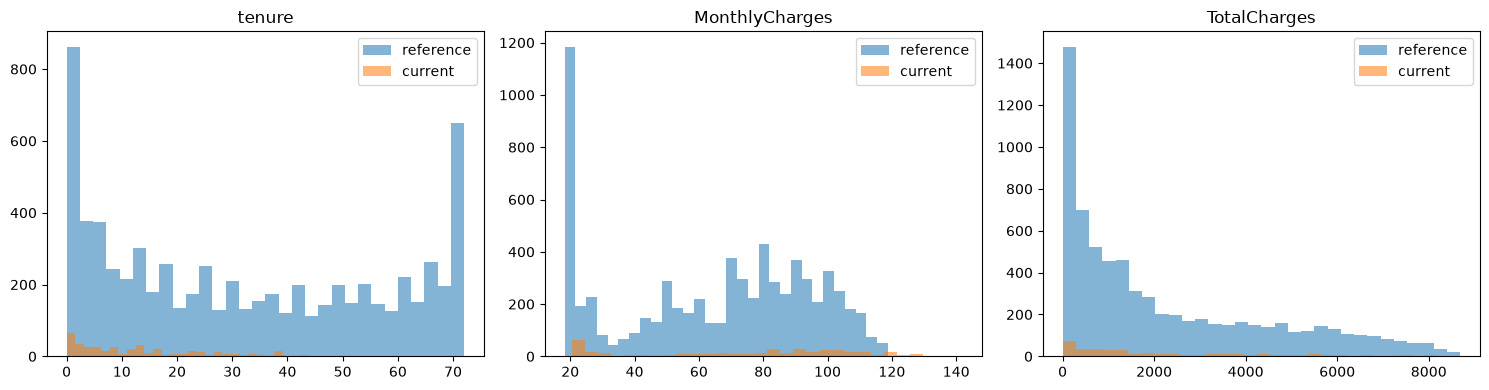

In [27]:
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15, 4))

for ax, feature in zip(axes, numeric_features):
    ax.hist(reference_df[feature], bins=30, alpha=0.55, label="reference")
    ax.hist(current_df[feature], bins=30, alpha=0.55, label="current")
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()

## 7. Categorical Drift Signals

For categorical features, we compare category shares. Large changes can indicate that the model is seeing a different population than during training.

In [28]:
def category_share_comparison(reference, current, feature):
    reference_share = reference[feature].value_counts(normalize=True).rename("reference_share")
    current_share = current[feature].value_counts(normalize=True).rename("current_share")
    comparison = pd.concat([reference_share, current_share], axis=1).fillna(0)
    comparison["absolute_difference"] = (comparison["current_share"] - comparison["reference_share"]).abs()
    return comparison.sort_values("absolute_difference", ascending=False)

category_share_comparison(reference_df, dashboard_df, "Contract")

,reference_share,current_share,absolute_difference
Contract,,,
Month-to-month,0.550192,0.7100,0.159808
One year,0.209144,0.1225,0.086644
Two year,0.240664,0.1675,0.073164


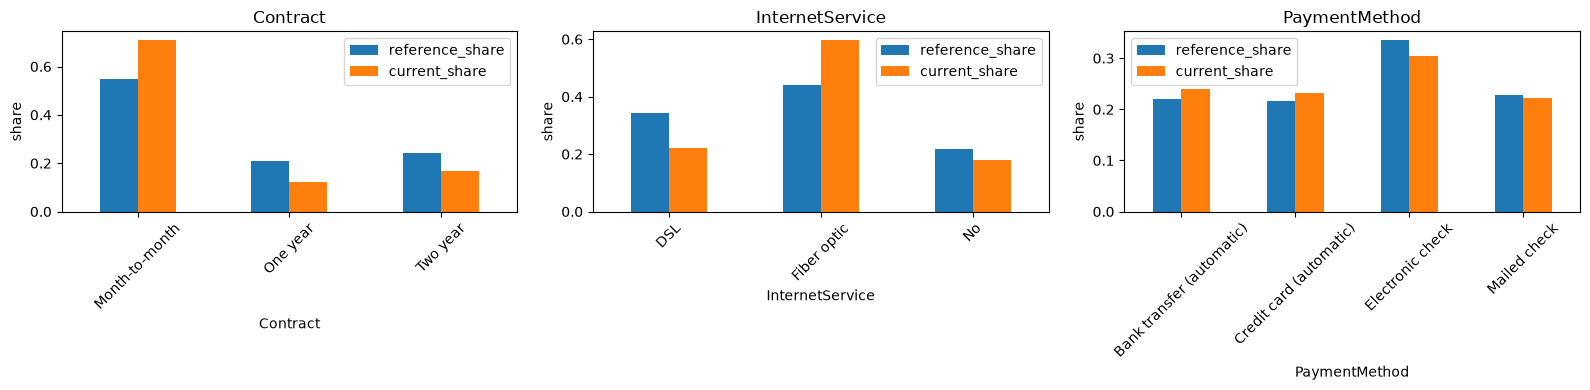

In [29]:
fig, axes = plt.subplots(1, len(categorical_features), figsize=(16, 4))

for ax, feature in zip(axes, categorical_features):
    comparison = category_share_comparison(reference_df, dashboard_df, feature).sort_index()
    comparison[["reference_share", "current_share"]].plot(kind="bar", ax=ax)
    ax.set_title(feature)
    ax.set_ylabel("share")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

## 8. Prediction Monitoring

Input drift asks whether the incoming data changed. Prediction monitoring asks whether model outputs changed.

Without ground-truth labels, this is not model performance monitoring. It is still useful: a sudden jump in average churn probability or churn-positive rate can be an operational signal.

In [30]:
if {"churn_probability", "churn_prediction"}.issubset(current_df.columns):
    prediction_summary = pd.DataFrame(
        [
            {
                "rows": len(current_df),
                "mean_churn_probability": current_df["churn_probability"].mean(),
                "predicted_churn_rate": current_df["churn_prediction"].mean(),
            }
        ]
    )
else:
    prediction_summary = pd.DataFrame()

prediction_summary

,rows,mean_churn_probability,predicted_churn_rate
0,400,0.42243,0.2975


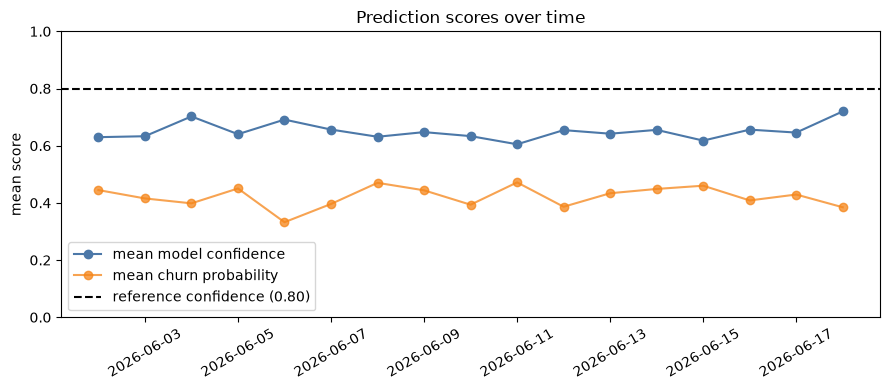

In [31]:
if not score_over_time.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(
        score_over_time["timestamp_utc"],
        score_over_time["model_confidence"],
        marker="o",
        label="mean model confidence",
        color="#4C78A8",
    )
    ax.plot(
        score_over_time["timestamp_utc"],
        score_over_time["churn_probability"],
        marker="o",
        label="mean churn probability",
        color="#F58518",
        alpha=0.75,
    )
    if not pd.isna(reference_mean_confidence):
        ax.axhline(
            reference_mean_confidence,
            color="black",
            linestyle="--",
            label=f"reference confidence ({reference_mean_confidence:.2f})",
        )
    ax.set_ylim(0, 1)
    ax.set_title("Prediction scores over time")
    ax.set_ylabel("mean score")
    ax.legend()
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

## 9. Monitoring Report Overview

A monitoring dashboard should first answer a few operational questions:

- How much current data is available?
- Which time window is covered?
- Which model-output signals changed?
- Which checks require investigation?

Detailed distribution plots come after this overview.

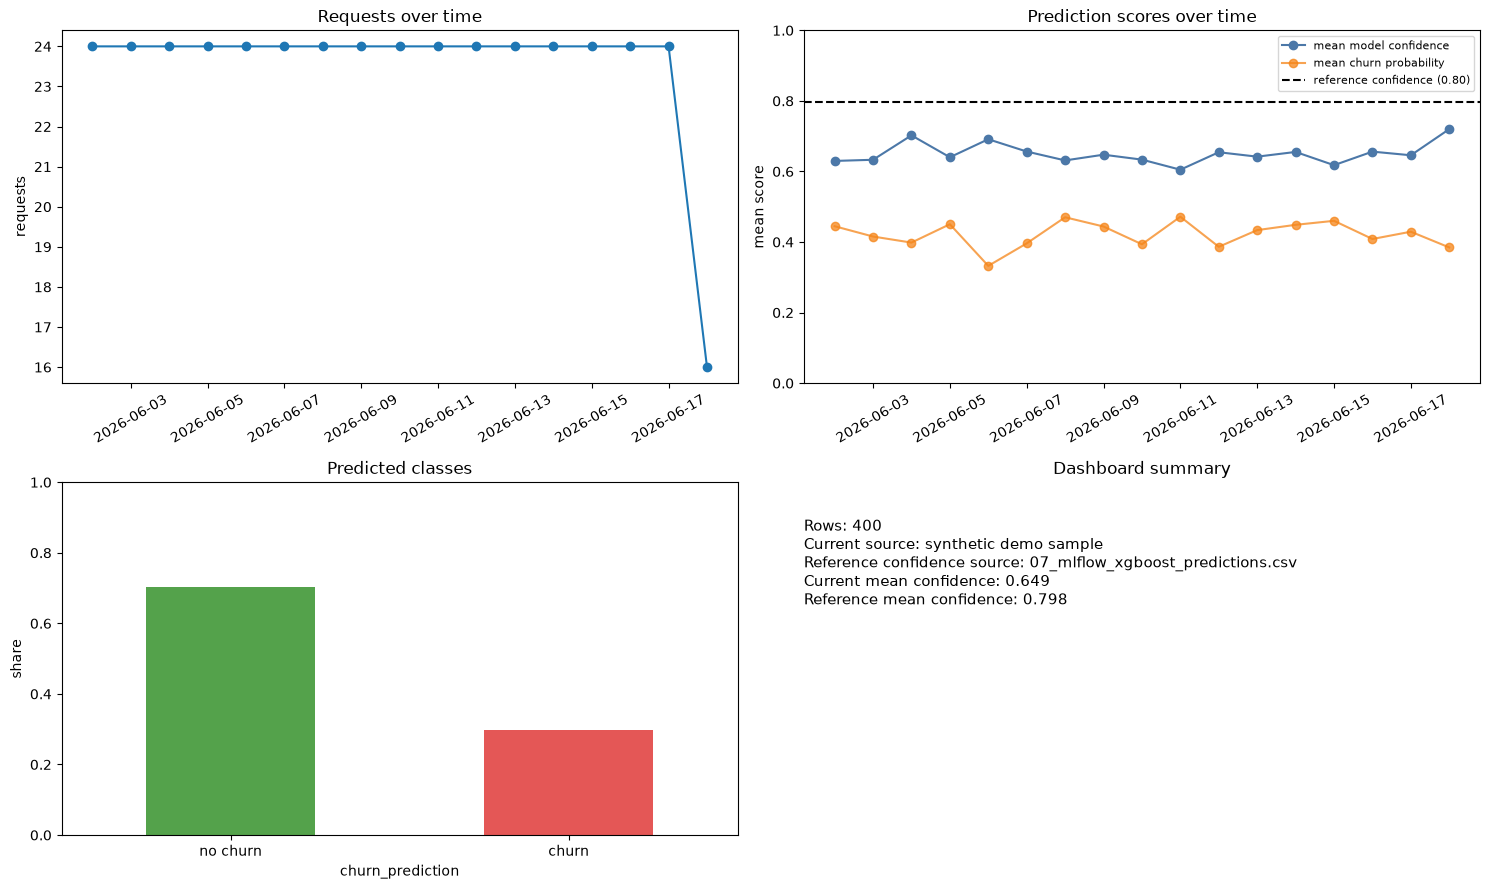

In [32]:
monitoring_overview = pd.DataFrame(
    [
        {
            "reference_rows": len(reference_df),
            "current_rows": len(dashboard_df),
            "current_source": current_source,
            "window_start": dashboard_df["timestamp_utc"].min(),
            "window_end": dashboard_df["timestamp_utc"].max(),
            "mean_churn_probability": dashboard_df["churn_probability"].mean() if "churn_probability" in dashboard_df.columns else np.nan,
            "mean_model_confidence": dashboard_df["model_confidence"].mean() if "model_confidence" in dashboard_df.columns else np.nan,
            "reference_mean_confidence": reference_mean_confidence,
            "predicted_churn_rate": dashboard_df["churn_prediction"].mean() if "churn_prediction" in dashboard_df.columns else np.nan,
            "reference_prediction_source": reference_confidence_source,
        }
    ]
)

monitoring_overview

## 10. Statistical Drift Tests

The following tests compare the reference data with the current inference data.

For continuous variables we use the **Kolmogorov-Smirnov test**. It compares two empirical distributions. A small p-value means that the current values are unlikely to come from the same distribution as the reference values.

For categorical variables we use a **chi-square test of independence**. It compares category counts between reference and current data. A small p-value means that the category mix has changed noticeably.

These tests are warning signals, not automatic model-quality verdicts. With very large samples even small differences can become statistically significant. With small samples relevant changes may still be hard to detect.

In [34]:
def drift_status(p_value, alpha=0.05):
    if pd.isna(p_value):
        return "not tested"
    return "investigate" if p_value < alpha else "ok"

ks_results = []
for feature in numeric_features:
    reference_values = reference_df[feature].dropna()
    current_values = dashboard_df[feature].dropna()
    if len(reference_values) == 0 or len(current_values) == 0:
        statistic, p_value = np.nan, np.nan
    else:
        statistic, p_value = ks_2samp(reference_values, current_values)
    ks_results.append(
        {
            "feature": feature,
            "test": "KS two-sample",
            "statistic": statistic,
            "p_value": p_value,
            "status": drift_status(p_value),
        }
    )

ks_results_df = pd.DataFrame(ks_results).sort_values("p_value")
ks_results_df

,feature,test,statistic,p_value,status
0,tenure,KS two-sample,0.373033,1.039089e-47,investigate
1,MonthlyCharges,KS two-sample,0.179779,3.571696e-11,investigate
2,TotalCharges,KS two-sample,0.034883,7.320323e-01,ok


In [35]:
chi2_results = []
for feature in categorical_features:
    reference_counts = reference_df[feature].value_counts()
    current_counts = dashboard_df[feature].value_counts()
    categories = sorted(set(reference_counts.index).union(current_counts.index))
    contingency = pd.DataFrame(
        {
            "reference": [reference_counts.get(category, 0) for category in categories],
            "current": [current_counts.get(category, 0) for category in categories],
        },
        index=categories,
    )

    if contingency.shape[0] < 2 or contingency.values.sum() == 0:
        statistic, p_value = np.nan, np.nan
    else:
        statistic, p_value, _, _ = chi2_contingency(contingency.T)

    chi2_results.append(
        {
            "feature": feature,
            "test": "chi-square",
            "statistic": statistic,
            "p_value": p_value,
            "status": drift_status(p_value),
        }
    )

chi2_results_df = pd.DataFrame(chi2_results).sort_values("p_value")
chi2_results_df

,feature,test,statistic,p_value,status
1,InternetService,chi-square,39.935424,2.128791e-09,investigate
0,Contract,chi-square,39.753685,2.331294e-09,investigate
2,PaymentMethod,chi-square,2.352143,5.026053e-01,ok


,feature,test,statistic,p_value,status
0,tenure,KS two-sample,0.373033,1.039089e-47,investigate
1,MonthlyCharges,KS two-sample,0.179779,3.571696e-11,investigate
2,TotalCharges,KS two-sample,0.034883,7.320323e-01,ok
3,InternetService,chi-square,39.935424,2.128791e-09,investigate
4,Contract,chi-square,39.753685,2.331294e-09,investigate
5,PaymentMethod,chi-square,2.352143,5.026053e-01,ok


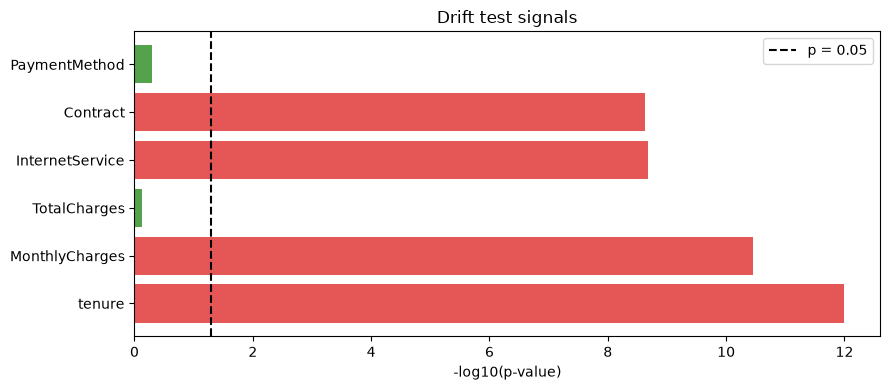

In [36]:
drift_test_results = pd.concat([ks_results_df, chi2_results_df], ignore_index=True)
drift_test_results["signal_type"] = "data_drift"
drift_test_results["metric"] = drift_test_results["test"]
drift_test_results["value"] = drift_test_results["p_value"]
drift_test_results["threshold"] = 0.05
drift_test_results["interpretation"] = np.where(
    drift_test_results["status"].eq("investigate"),
    "Current distribution differs from the reference distribution.",
    "No strong distribution difference detected by this test.",
)

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = drift_test_results.copy().sort_values("p_value", ascending=True)
plot_df["minus_log10_p_value"] = -np.log10(plot_df["p_value"].clip(lower=1e-12))
colors = plot_df["status"].map({"ok": "#54A24B", "investigate": "#E45756", "not tested": "#BDBDBD"})

ax.barh(plot_df["feature"], plot_df["minus_log10_p_value"], color=colors)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", label="p = 0.05")
ax.set_xlabel("-log10(p-value)")
ax.set_title("Feature drift ranking")
ax.legend()
plt.tight_layout()

drift_test_results.sort_values("p_value")

## 11. Alert Table

A practical monitoring workflow usually ends in a prioritized list of signals. This table combines data quality, data drift, and prediction monitoring checks into one place.

In [ ]:
prediction_alert_rows = []
if "model_confidence" in dashboard_df.columns and not pd.isna(reference_mean_confidence):
    confidence_drop = reference_mean_confidence - dashboard_df["model_confidence"].mean()
    prediction_alert_rows.append(
        {
            "signal_type": "prediction_monitoring",
            "feature": "model_confidence",
            "metric": "reference_minus_current_mean",
            "value": confidence_drop,
            "threshold": 0.10,
            "status": "investigate" if confidence_drop > 0.10 else "ok",
            "interpretation": "Current confidence is lower than the reference confidence.",
        }
    )

if "churn_prediction" in dashboard_df.columns and not pd.isna(reference_predicted_churn_rate):
    churn_rate_shift = abs(dashboard_df["churn_prediction"].mean() - reference_predicted_churn_rate)
    prediction_alert_rows.append(
        {
            "signal_type": "prediction_monitoring",
            "feature": "churn_prediction",
            "metric": "absolute_predicted_rate_shift",
            "value": churn_rate_shift,
            "threshold": 0.10,
            "status": "investigate" if churn_rate_shift > 0.10 else "ok",
            "interpretation": "Predicted churn rate shifted compared with the reference predictions.",
        }
    )

prediction_monitoring_results = pd.DataFrame(prediction_alert_rows)

alert_table = pd.concat(
    [
        data_quality_results[["signal_type", "feature", "metric", "value", "threshold", "status", "interpretation"]],
        drift_test_results[["signal_type", "feature", "metric", "value", "threshold", "status", "interpretation"]],
        prediction_monitoring_results,
    ],
    ignore_index=True,
)

status_order = {"investigate": 0, "not tested": 1, "ok": 2}
alert_table["status_order"] = alert_table["status"].map(status_order).fillna(3)
alert_table = alert_table.sort_values(["status_order", "signal_type", "feature"]).drop(columns="status_order")
alert_table

In [ ]:
alert_status_summary = (
    alert_table["status"]
    .value_counts()
    .reindex(["investigate", "not tested", "ok"], fill_value=0)
    .rename_axis("status")
    .reset_index(name="count")
)

alert_status_summary

## 12. How to Read This Dashboard

A red signal does not mean that the model is broken. It means that the current inference population differs from the reference population for that feature.

Useful follow-up questions are:

- Is this drift expected from a campaign, pricing change, or seasonality?
- Does the drift affect important customer groups?
- Do model scores and business KPIs change at the same time?
- Do we need more labeled feedback before retraining?

In production, this kind of notebook would usually become a scheduled report or dashboard. The raw material would still be the same: logged requests, predictions, model version, and later realized outcomes.

## 13. Sources and Tool Inspiration

This notebook is a small didactic mockup. It does not replace a production monitoring platform.

The structure is inspired by common patterns in current ML monitoring and observability tools:

- Evidently AI: data quality, data drift, prediction monitoring, report-style dashboards.  
  https://www.evidentlyai.com/
- NannyML: post-deployment monitoring, delayed labels, and the idea that drift should be interpreted through performance or business impact.  
  https://www.nannyml.com/
- Azure ML Model Monitoring: data drift, prediction drift, data quality, feature attribution, reference data, and alert thresholds.  
  https://learn.microsoft.com/en-us/azure/machine-learning/concept-model-monitoring
- AWS SageMaker Model Monitor: baseline data, constraints, scheduled monitoring, reports, and alerts.  
  https://docs.aws.amazon.com/sagemaker/latest/dg/model-monitor.html
- Google Vertex AI Model Monitoring: baseline/current distributions, drift thresholds, and feature-level monitoring.  
  https://cloud.google.com/vertex-ai/docs/model-monitoring/overview

The recurring pattern is simple: collect inference data, compare it to a reference, prioritize suspicious signals, and investigate before deciding on retraining or rollback.

## 14. Production Outlook

This project uses SQLite because it is simple and local. For the course, it makes the data flow visible:

```text
incoming request -> prediction -> SQLite log -> monitoring notebook
```

In a cloud deployment, the same idea would usually use a central sink:

- Azure PostgreSQL or Azure SQL for structured request/prediction logs;
- Azure Blob Storage for larger event files;
- Event Hub or Application Insights for higher-volume operational telemetry.

The API would not hard-code this. It would read a configuration value such as `MONITORING_DB_PATH`, `MONITORING_DB_URI`, or `MONITORING_SINK_URI` from the deployment environment.

The important design distinction remains:

- model artifacts are read-only inputs to inference;
- monitoring logs are writable outputs of the running service.

## 15. Reflection

Monitoring does not make a model better by itself. It helps teams notice when they should investigate.

Useful questions are:

- Are incoming customers still similar to the training data?
- Are prediction probabilities shifting over time?
- Is one segment becoming much more common?
- Do we need new labels to check actual model quality?
- Should retraining or a threshold review be triggered?

This is why a model can be technically healthy but professionally risky: it may continue to respond while its assumptions become less valid.